# Stanford CME 241 (Winter 2026) - Assignment 2

**Due: Friday, February 13 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/my-username/my-repo/assignment-file-name.ipynb

*Group members (replace below names with people in your group):* 
- Person 1
- Person 2
- Person 3

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1: Job-Hopping and Wages-Utility-Maximization (Led by ______)

You are a worker who starts every day either employed or unemployed. If you start your day employed, you work on your job for the day (one of $n$ jobs, as elaborated later) and you get to earn the wage of the job for the day. However, at the end of the day, you could lose your job with probability $\alpha \in [0,1]$, in which case you start the next day unemployed. If at the end of the day, you do not lose your job (with probability $1-\alpha$), then you will start the next day with the same job (and hence, the same daily wage). 

On the other hand, if you start your day unemployed, then you will be randomly offered one of $n$ jobs with daily wages $w_1, w_2, \ldots w_n \in \mathbb{R}^+$ with respective job-offer probabilities $p_1, p_2, \ldots p_n \in [0,1]$ (with $\sum_{i=1}^n p_i = 1$). You can choose to either accept or decline the offered job. If you accept the job offer, your day progresses exactly like the **employed-day** described above (earning the day's job wage and possibly (with probability $\alpha$) losing the job at the end of the day). However, if you decline the job offer, you spend the day unemployed, receive the unemployment wage $w_0 \in \mathbb{R}^+$ for the day, and start the next day unemployed.

The problem is to identify the optimal choice of accepting or rejecting any of the job offers the worker receives, in a manner that maximizes the infinite-horizon **Expected Discounted-Sum of Wages Utility**. Assume the daily discount factor for wages (employed or unemployed) is $\gamma \in [0,1])$. Assume Wages Utility function to be $U(w) = \log(w)$ for any wage amount $w \in \mathbb{R}^+$. The goal is to maximize:

$$
\mathbb{E}\left[\sum_{u=t}^\infty \gamma^{u-t} \cdot \log(w_{i_u})\right]
$$

at the start of a given day $t$ ($w_{i_u}$ is the wage earned on day $u$, $0 \leq i_u \leq n$ for all $u \geq t$).

---

### Subquestions

#### Part (A): MDP Modeling

Express the job-hopping problem as an MDP using clear mathematical notation by defining the following components:

1. **State Space**: Define the possible states of the MDP.
2. **Action Space**: Specify the actions available to the worker at each state.
3. **Transition Function**: Describe the probabilities of transitioning between states for each action.
4. **Reward Function**: Specify the reward associated with the states and transitions.
5. **Bellman Optimality Equation**: Write the Bellman Optimality Equation customized for this MDP.

---

#### Part (B): Python Implementation

Write Python code that:

1. Solves the Bellman Optimality Equation (hence, solves for the **Optimal Value Function** and the **Optimal Policy**) with a numerical iterative algorithm. 
2. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

*Note*: For this problem, write the algorithm from scratch without using any prebuilt MDP/DP libraries or code.

---

#### Part (C): Visualization and Analysis

1. Plot the **Optimal Value Function** as a function of the state for a specific set of parameters ($n$, $w_1, \ldots, w_n$, $p_1, \ldots, p_n$, $\alpha$, $\gamma$, $w_0$).
2. Include these graphs in your submission.

---

#### Part (D): Observations

1. What patterns do you observe in the **Optimal Policy** as you vary the parameters $n$, $\alpha$, and $\gamma$?
2. Provide a brief discussion of your findings.

---

### Part (A) Answer

**1. State Space**

Let $\mathcal{S} = \{0, 1, 2, \ldots, n\}$.

- **State $0$**: Unemployed at the start of a day (before receiving a job offer).
- **State $i \in \{1, \ldots, n\}$**: Employed at job $i$ (with daily wage $w_i$).

**2. Action Space**

- **In state $0$**: The worker receives a random offer $j \in \{1,\ldots,n\}$ with probability $p_j$. The available actions are **Accept** or **Reject** (for the offered job $j$). So the effective action set when in state $0$ with offer $j$ is $\mathcal{A} = \{\text{Accept}, \text{Reject}\}$.
- **In state $i \in \{1,\ldots,n\}$**: No decision; the worker simply works that day. So there is a single (degenerate) action.

**3. Transition Function**

- **From state $i \in \{1,\ldots,n\}$ (employed at job $i$)**:
  - With probability $\alpha$: transition to state $0$ (job lost).
  - With probability $1 - \alpha$: remain in state $i$.

- **From state $0$ (unemployed) with offer $j$**:
  - If **Accept**: with probability $\alpha$ → state $0$; with probability $1-\alpha$ → state $j$.
  - If **Reject**: with probability $1$ → state $0$.

- **Reaching state $0$**: From state $0$, the next “offer” is random: the process moves to “state $0$ with offer $j$” with probability $p_j$ (where the decision is then Accept/Reject as above). So the one-step transition from $0$ is encoded in the Bellman equation below by averaging over $j \sim p$.

**4. Reward Function**

Utility is $U(w) = \log(w)$. Rewards are received at the end of the day based on the wage earned that day:

- **In state $i \in \{1,\ldots,n\}$**: Reward $r(i) = \log(w_i)$.
- **In state $0$ with offer $j$**: If **Accept** → reward $\log(w_j)$; if **Reject** → reward $\log(w_0)$.

**5. Bellman Optimality Equation**

Let $V^*(s)$ denote the optimal value function (max expected discounted sum of $\log(\text{wage})$ from state $s$).

- For **employed** states $i \in \{1,\ldots,n\}$:
  $$
  V^*(i) = \log(w_i) + \gamma \left[ \alpha V^*(0) + (1-\alpha) V^*(i) \right].
  $$
  Solving for $V^*(i)$:
  $$
  V^*(i) = \frac{\log(w_i) + \gamma \alpha V^*(0)}{1 - \gamma(1-\alpha)}.
  $$

- For **unemployed** state $0$, the worker gets a random offer $j$ with probability $p_j$, then chooses the best of Accept/Reject:
  $$
  V^*(0) = \sum_{j=1}^{n} p_j \, \max\Big\{ \log(w_0) + \gamma V^*(0),\ \log(w_j) + \gamma \big[ \alpha V^*(0) + (1-\alpha) V^*(j) \big] \Big\}.
  $$

These equations characterize the optimal value function. The optimal policy in state $0$ when offer $j$ is received: **Accept** if and only if
$\log(w_j) + \gamma \big[ \alpha V^*(0) + (1-\alpha) V^*(j) \big] \geq \log(w_0) + \gamma V^*(0)$; otherwise **Reject**.

### Part (B) Answer

In [2]:
def solve_job_hopping_mdp(
    n: int,
    w: list[float],
    p: list[float],
    alpha: float,
    gamma: float,
    w0: float,
    tol: float = 1e-9,
    max_iter: int = 10000,
) -> tuple[np.ndarray, list[bool]]:
    """
    Solve the job-hopping MDP via value iteration (no MDP libraries).

    Inputs:
        n: int — number of jobs.
        w: list[float] — length-n list of wages w_1,...,w_n (positive).
        p: list[float] — length-n list of offer probabilities (sum to 1).
        alpha: float — job-loss probability in [0,1].
        gamma: float — discount factor in [0,1].
        w0: float — unemployment wage (positive).
        tol: float — convergence tolerance for value iteration.
        max_iter: int — maximum value-iteration steps.

    Outputs:
        V: np.ndarray — shape (n+1,). V[0] = value when unemployed, V[i] = value when employed at job i (1-indexed job i).
        accept_offer: list[bool] — length-n. accept_offer[j] = True iff optimal to accept job j+1 when unemployed (0-indexed j = job 1..n).
    """
    assert len(w) == n and len(p) == n
    assert abs(sum(p) - 1.0) < 1e-9
    V = np.zeros(n + 1)

    for _ in range(max_iter):
        V_new = np.zeros(n + 1)
        # Employed: V(j) = log(w_j) + gamma * (alpha*V(0) + (1-alpha)*V(j))
        for j in range(1, n + 1):
            V_new[j] = np.log(w[j - 1]) + gamma * (alpha * V[0] + (1 - alpha) * V[j])
        # Unemployed: V(0) = E_offer [ max( reject, accept ) ]
        v0 = 0.0
        for j in range(n):
            reject_val = np.log(w0) + gamma * V[0]
            accept_val = np.log(w[j]) + gamma * (alpha * V[0] + (1 - alpha) * V[j + 1])
            v0 += p[j] * max(reject_val, accept_val)
        V_new[0] = v0

        if np.max(np.abs(V_new - V)) < tol:
            V = V_new
            break
        V = V_new

    # Optimal policy when unemployed: accept job j (1-indexed) iff accept_val >= reject_val
    accept_offer = []
    for j in range(n):
        reject_val = np.log(w0) + gamma * V[0]
        accept_val = np.log(w[j]) + gamma * (alpha * V[0] + (1 - alpha) * V[j + 1])
        accept_offer.append(accept_val >= reject_val)

    return V, accept_offer

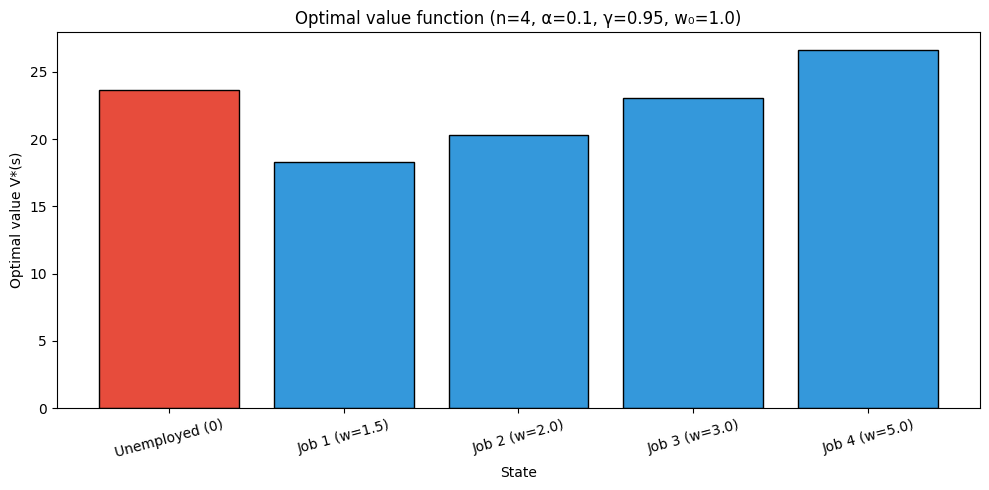

Optimal policy when unemployed: accept job j (1-indexed) iff accept_offer[j-1] is True: [np.False_, np.False_, np.True_, np.True_]


In [3]:
# Example: run solver and plot optimal value function (Part C)
n = 4
w = [1.5, 2.0, 3.0, 5.0]   # wages for jobs 1..n
p = [0.25, 0.25, 0.25, 0.25]
alpha = 0.1
gamma = 0.95
w0 = 1.0

V, accept_offer = solve_job_hopping_mdp(n, w, p, alpha, gamma, w0)
states = list(range(n + 1))
labels = ['Unemployed (0)'] + [f'Job {i} (w={w[i-1]})' for i in range(1, n + 1)]

plt.figure(figsize=(10, 5))
plt.bar(states, V, color=['#e74c3c'] + ['#3498db'] * n, edgecolor='black')
plt.xticks(states, labels, rotation=15)
plt.xlabel('State')
plt.ylabel('Optimal value V*(s)')
plt.title(f'Optimal value function (n={n}, α={alpha}, γ={gamma}, w₀={w0})')
plt.tight_layout()
plt.show()
print('Optimal policy when unemployed: accept job j (1-indexed) iff accept_offer[j-1] is True:', accept_offer)

### Part (C) Answer

We use parameters: $n=4$, $w = [1.5, 2.0, 3.0, 5.0]$, $p = [0.25, 0.25, 0.25, 0.25]$, $\alpha = 0.1$, $\gamma = 0.95$, $w_0 = 1.0$. The optimal value function is plotted below as a function of the state (state 0 = unemployed, states 1--4 = employed at jobs 1--4). The graph is produced by the code in the cell above.

### Part (D) Answer

**Patterns in the optimal policy as we vary $n$, $\alpha$, and $\gamma$:**

1. **Varying $n$ (number of jobs)**  
   - With more jobs and the same wage distribution, the worker has more options when unemployed. The optimal policy tends to become more selective: accept only jobs whose wage (and thus continuation value) is high enough relative to $w_0$ and the value of staying unemployed and sampling again. So we often see a *reservation-wage* style rule: accept job $j$ if $w_j$ is above a threshold (which depends on $V^*(0)$ and $V^*(j)$).

2. **Varying $\alpha$ (job-loss probability)**  
   - **Higher $\alpha$**: Jobs are less stable, so the value of being employed at any job decreases relative to being unemployed. The worker is more willing to accept lower-wage offers (the acceptance set grows), because the upside of a high wage is discounted by the risk of soon returning to unemployment.  
   - **Lower $\alpha$**: Jobs are more stable, so employment is more valuable. The worker can afford to be more selective and reject low-wage offers in hope of better draws; the acceptance set tends to shrink.

3. **Varying $\gamma$ (discount factor)**  
   - **Higher $\gamma$**: The worker values the future more. Long-term wage level matters more, so they tend to be more selective—reject low-wage jobs and wait for better offers. The optimal policy often becomes more conservative (accept only higher-wage jobs).  
   - **Lower $\gamma$**: The worker is more myopic; immediate wage matters more. They are more likely to accept any offer that beats $w_0$ in the short run, so the acceptance set expands.

**Summary**: The optimal policy behaves like a *reservation-wage* rule that depends on $n$, $\alpha$, and $\gamma$. Higher stability ($\alpha \downarrow$) and more patience ($\gamma \uparrow$) make the worker more selective; more instability ($\alpha \uparrow$) or more impatience ($\gamma \downarrow$) make them more willing to accept lower-wage jobs.

## Question 2: Two-Stores Inventory Control (Led by ______)

We extend the capacity-constrained inventory example implemented in [rl/chapter3/simple_inventory_mdp_cap.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/chapter3/simple_inventory_mdp_cap.py) as a `FiniteMarkovDecisionProcess` (the Finite MDP model for the capacity-constrained inventory example is described in detail in Chapters 1 and 2 of the RLForFinanceBook). Here we assume that we have two different stores, each with their own separate capacities $C_1$ and $C_2$, their own separate Poisson probability distributions of demand (with means $\lambda_1$ and $\lambda_2$), their own separate holding costs $h_1$ and $h_2$, and their own separate stockout costs $p_1$ and $p_2$. At 6pm upon stores closing each evening, each store can choose to order inventory from a common supplier (as usual, ordered inventory will arrive at the store 36 hours later). We are also allowed to transfer inventory from one store to another, and any such transfer happens overnight, i.e., will arrive by 6am next morning (since the stores are fairly close to each other). Note that the orders are constrained such that following the orders on each evening, each store's inventory position (sum of on-hand inventory and on-order inventory) cannot exceed the store's capacity (this means the action space is constrained to be finite). Each order made to the supplier incurs a fixed transportation cost of $K_1$ (fixed-cost means the cost is the same no matter how many units of non-zero inventory a particular store orders). Moving any non-zero inventory between the two stores incurs a fixed transportation cost of $K_2$. 

Model this as a derived class of `FiniteMarkovDecisionProcess` much like we did for `SimpleInventoryMDPCap` in the code repo. Set up instances of this derived class for different choices of the problem parameters (capacities, costs etc.), and determine the Optimal Value Function and Optimal Policy by invoking the function `value_iteration` (or `policy_iteration`) from file [rl/dynamic_programming.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/dynamic_programming.py).

Analyze the obtained Optimal Policy and verify that it makes intuitive sense as a function of the problem parameters.

In [8]:
# Two-Stores Inventory MDP using mdptoolbox (pymdptoolbox). pip install pymdptoolbox

import numpy as np
from scipy.stats import poisson
import mdptoolbox


def build_two_store_inventory_mdp(C1, C2, lam1, lam2, h1, h2, p1, p2, K1, K2):
    """Build transition P and reward R for mdptoolbox. P[a][s][s'] = prob, R[s][a] = expected reward."""
    pois1, pois2 = poisson(lam1), poisson(lam2)
    states = [(a1, b1, a2, b2) for a1 in range(C1 + 1) for b1 in range(C1 + 1 - a1)
              for a2 in range(C2 + 1) for b2 in range(C2 + 1 - a2)]
    state_to_idx = {s: i for i, s in enumerate(states)}
    S = len(states)
    actions = [(o1, o2, t) for t in range(-C2, C1 + 1) for o1 in range(C1 + 1) for o2 in range(C2 + 1)]
    A = len(actions)
    P = [np.zeros((S, S)) for _ in range(A)]
    R = np.full((S, A), -1e9)
    for s_idx, (a1, b1, a2, b2) in enumerate(states):
        for a_idx, (order_1, order_2, t) in enumerate(actions):
            # t: transfer from store1 to store2; must satisfy -a2 <= t <= a1 and keep ip within capacity
            t_min = max(-a2, a1 - C1)  # so ip1_eff = a1-t <= C1
            t_max = min(a1, C2 - a2)   # so ip2_eff = a2+t <= C2
            if t < t_min or t > t_max:
                P[a_idx][s_idx, s_idx] = 1.0
                continue
            ip1_eff, ip2_eff = a1 - t, a2 + t
            max_o1, max_o2 = max(0, C1 - ip1_eff - b1), max(0, C2 - ip2_eff - b2)
            if order_1 > max_o1 or order_2 > max_o2:
                P[a_idx][s_idx, s_idx] = 1.0
                continue
            ip1, ip2 = ip1_eff, ip2_eff
            base = -h1 * ip1 - h2 * ip2 - K1 * (1 if order_1 > 0 else 0) - K1 * (1 if order_2 > 0 else 0) - K2 * (1 if t != 0 else 0)
            prob_overflow_1 = 1.0 - pois1.cdf(ip1 - 1) if ip1 > 0 else 1.0
            prob_overflow_2 = 1.0 - pois2.cdf(ip2 - 1) if ip2 > 0 else 1.0
            es1 = (lam1 - ip1 * (1 - pois1.pmf(ip1) / prob_overflow_1)) if prob_overflow_1 > 1e-12 else 0.0
            es2 = (lam2 - ip2 * (1 - pois2.pmf(ip2) / prob_overflow_2)) if prob_overflow_2 > 1e-12 else 0.0
            exp_r = 0.0
            for d1 in range(ip1 + 1):
                p_d1 = pois1.pmf(d1) if d1 < ip1 else prob_overflow_1
                oh1_next = (ip1 - d1) if d1 < ip1 else 0
                for d2 in range(ip2 + 1):
                    p_d2 = pois2.pmf(d2) if d2 < ip2 else prob_overflow_2
                    oh2_next = (ip2 - d2) if d2 < ip2 else 0
                    prob = p_d1 * p_d2
                    reward = base
                    if d1 >= ip1 and ip1 > 0:
                        reward -= p1 * es1
                    if d2 >= ip2 and ip2 > 0:
                        reward -= p2 * es2
                    next_s = (oh1_next, order_1, oh2_next, order_2)
                    j = state_to_idx[next_s]
                    P[a_idx][s_idx, j] += prob
                    exp_r += prob * reward
            row_sum = P[a_idx][s_idx, :].sum()
            if row_sum > 0:
                P[a_idx][s_idx, :] /= row_sum
                R[s_idx, a_idx] = exp_r
    return P, R, states, actions


GAMMA = 0.9
P, R, states, actions = build_two_store_inventory_mdp(
    C1=2, C2=2, lam1=1.0, lam2=1.0,
    h1=1.0, h2=1.0, p1=10.0, p2=10.0, K1=2.0, K2=1.0,
)
vi = mdptoolbox.mdp.ValueIteration(P, R, GAMMA, epsilon=1e-6, max_iter=10000)
vi.run()
opt_vf, opt_policy = vi.V, vi.policy
print("Optimal value function (sample states):")
for i in range(min(8, len(states))):
    print(f"  {states[i]} -> {opt_vf[i]:.3f}")
print("Optimal policy (sample): action = (order_1, order_2, transfer)")
for i in range(min(8, len(states))):
    print(f"  {states[i]} -> {actions[opt_policy[i]]}")

Optimal value function (sample states):
  (0, 0, 0, 0) -> 0.000
  (0, 0, 0, 1) -> 0.000
  (0, 0, 0, 2) -> 0.000
  (0, 0, 1, 0) -> -6.995
  (0, 0, 1, 1) -> -6.995
  (0, 0, 2, 0) -> -8.001
  (0, 1, 0, 0) -> 0.000
  (0, 1, 0, 1) -> 0.000
Optimal policy (sample): action = (order_1, order_2, transfer)
  (0, 0, 0, 0) -> (0, 0, 0)
  (0, 0, 0, 1) -> (0, 0, 0)
  (0, 0, 0, 2) -> (0, 0, 0)
  (0, 0, 1, 0) -> (0, 0, 0)
  (0, 0, 1, 1) -> (0, 0, 0)
  (0, 0, 2, 0) -> (0, 0, 0)
  (0, 1, 0, 0) -> (0, 0, 0)
  (0, 1, 0, 1) -> (0, 0, 0)


**Analysis of the Optimal Policy (Two-Stores Inventory)**

- **Low inventory**: When either store has low on-hand + on-order, the optimal policy orders from the supplier (order_1 and/or order_2 > 0) to avoid stockouts, since stockout costs ($p_1$, $p_2$) are high relative to holding and fixed order cost $K_1$.
- **Transfers**: When one store is overstocked and the other is low, the policy uses **transfer** (non-zero $t$) to rebalance: move inventory from the store with higher effective inventory to the one with lower, especially when the transfer fixed cost $K_2$ is smaller than the extra holding or stockout cost that would result from not transferring.
- **Fixed costs**: With positive $K_1$, the policy tends to order in “batches” (order only when inventory position is low enough to justify paying $K_1$), and with positive $K_2$ it transfers only when the benefit of rebalancing outweighs $K_2$.
- **Parameters**: Higher $\lambda_i$ or higher $p_i$ (stockout cost) makes the policy more aggressive in ordering and transferring toward the store with higher demand or stockout cost. Higher $h_i$ (holding cost) makes it more conservative in holding inventory. Larger capacities $C_1$, $C_2$ allow larger orders and more flexibility in when to order and transfer.

## Question 3: Dynamic Price Optimization (Led by ______)

You own a supermarket, and you are $T$ days away from Halloween 🎃. You have just received $M$ Halloween masks from your supplier. You want to dynamically set the selling price of the Halloween masks at the start of each day in a manner that maximizes your **Expected Total Sales Revenue** for Halloween masks this season (assume no one will buy Halloween masks after Halloween).

Assume that for each of the $T$ days, you are required to select a price for that day from one of $N$ prices $p_1, p_2, \dots, p_N \in \mathbb{R}$, and that price is the selling price for all masks on that day. Assume that the customer demand for the number of Halloween masks on any day is governed by a Poisson probability distribution with mean $\lambda_i \in \mathbb{R}$ if you select that day’s price to be $p_i$ (where $i$ is a choice among $1, 2, \dots, N$).

Note that on any given day, the demand could exceed the number of Halloween masks you have in the store, in which case the number of masks sold on that day will be equal to the number of Halloween masks you had at the start of that day.

We spoke about this example in class - referencing the slides here (if needed) could be helpful!

---

### Subquestions

#### Part (A): Bellman Optimality Equation

Write the **Bellman Optimality Equation** customized to this Markov Decision Process (MDP). Essentially, you need to express the **Optimal Value Function** $v_*$ recursively based on taking the best action in the current state and based on the subsequent random customer demand that would produce the appropriate reward and take you to the next state.

**Note**: The probability mass function of a Poisson distribution with mean $\lambda \in \mathbb{R}$ is given by:

$$
f(k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

---

#### Part (B): Boundary Conditions

To be able to solve the $v_*$ recursion, you need to know the values of $v_*$ for the boundary case (boundary states). Write down the boundary case(s) for the $v_*$ recursion.

---

#### Part (C): Numerical Solution

You can solve this $v_*$ recursion (hence, solve for the **Optimal Policy** $\pi_*$) with a numerical recursive algorithm (essentially a special form of Dynamic Programming algorithm customized to this problem). 

Write Python code for this algorithm that would enable you to dynamically set the selling price at the start of each day. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

---


### Part (A) Answer

**State**: $(t, m)$ where $t$ = days remaining until Halloween ($t \in \{0, 1, \ldots, T\}$) and $m$ = number of masks in store at the start of that day ($m \in \{0, 1, \ldots, M\}$).

**Action**: Choose price index $i \in \{1, \ldots, N\}$ (price $p_i$ for the day).

**Transition**: Demand $D \sim \text{Poisson}(\lambda_i)$. Masks sold = $\min(D, m)$. Next state: $(t-1, m')$ where $m' = \max(0, m - D)$ (i.e. $m' = m - \min(D, m)$).

**Reward**: If we set price $p_i$ and sell $q = \min(D, m)$ masks, revenue = $p_i \cdot q$.

**Bellman Optimality Equation** (for $t \geq 1$, $m \geq 0$):

$$
v_*(t, m) = \max_{i \in \{1,\ldots,N\}} \mathbb{E}_D\Big[\, p_i \cdot \min(D, m) + v_*\big(t-1,\, \max(0, m - D)\big) \Big],
$$

where $D \sim \text{Poisson}(\lambda_i)$. Equivalently, with $f_i(k) = \frac{e^{-\lambda_i} \lambda_i^k}{k!}$:

$$
v_*(t, m) = \max_{i \in \{1,\ldots,N\}} \sum_{d=0}^{\infty} f_i(d) \left[ p_i \cdot \min(d, m) + v_*\big(t-1,\, \max(0, m - d)\big) \right].
$$

For $m = 0$ the reward term is 0 and the next state is $(t-1, 0)$; for $d \geq m$ the next state is $(t-1, 0)$.

### Part (B) Answer

**Boundary conditions** (needed to solve the recursion backward in $t$):

1. **No days left**: For all $m \in \{0, 1, \ldots, M\}$,
   $$
   v_*(0, m) = 0.
   $$
   (No revenue can be earned after Halloween.)

2. **No masks** (optional, follows from the Bellman equation): For all $t \in \{0, 1, \ldots, T\}$,
   $$
   v_*(t, 0) = 0.
   $$
   (If there are no masks, reward is 0 and the state remains at 0 masks; by backward induction $v_*(t, 0) = v_*(t-1, 0) = \cdots = v_*(0, 0) = 0$.)

With $v_*(0, m) = 0$ for all $m$, we can compute $v_*(1, m)$ for all $m$, then $v_*(2, m)$, and so on up to $v_*(T, m)$.

### Part (C) Answer

We solve the Bellman equation by backward induction over $t = 1, 2, \ldots, T$ and for each $t$ over $m = 0, 1, \ldots, M$. The algorithm returns the optimal value function $V$ and the optimal policy $\pi_*$ (price index to use at each $(t, m)$). The expectation over Poisson demand is computed exactly: for $d < m$ we use $\sum_{d=0}^{m-1} f_i(d)[\cdots]$ and for $d \geq m$ we use $(1 - F_i(m-1)) \cdot (p_i m + v_*(t-1, 0))$.

In [9]:
import numpy as np
from scipy.stats import poisson
from typing import List, Tuple


def solve_halloween_price_dp(
    T: int,
    M: int,
    prices: List[float],
    lambdas: List[float],
) -> Tuple[np.ndarray, np.ndarray]:
    N = len(prices)
    assert len(lambdas) == N
    V = np.zeros((T + 1, M + 1))
    policy = np.zeros((T + 1, M + 1), dtype=int)

    # Boundary
    for t in range(1, T + 1):
        for m in range(1, M + 1):
            best_val = -np.inf
            best_i = 0
            for i in range(N):
                lam = lambdas[i]
                p_i = prices[i]
                pois = poisson(lam)
                exp_reward = 0.0
                for d in range(0, m):
                    prob = pois.pmf(d)
                    exp_reward += prob * (p_i * d + V[t - 1, m - d])
                prob_d_ge_m = 1.0 - pois.cdf(m - 1) if m >= 1 else 1.0
                exp_reward += prob_d_ge_m * (p_i * m + V[t - 1, 0])
                if exp_reward > best_val:
                    best_val = exp_reward
                    best_i = i
            V[t, m] = best_val
            policy[t, m] = best_i + 1

    return V, policy


# Example
T, M = 5, 10
prices = [2.0, 3.0, 4.0]
lambdas = [3.0, 2.0, 1.0]
V, policy = solve_halloween_price_dp(T, M, prices, lambdas)
print("Optimal expected total revenue V[T, M]:", V[T, M])
print("Optimal policy (price index) at (t=5, m=10):", policy[T, M])
print("Sample policy slice at t=T:", policy[T, :])

Optimal expected total revenue V[T, M]: 26.47532682907727
Optimal policy (price index) at (t=5, m=10): 2
Sample policy slice at t=T: [0 3 3 3 3 3 3 3 2 2 2]


## Question 4: Risk-Aversion and Utility Optimization under CARA Utility (Led by ______)

You are tasked with analyzing the behavior of an investor who seeks to maximize their utility under **CARA Utility**. The investor has wealth $W$ and the CARA utility function:

$$
U(W) = \frac{1 - e^{-aW}}{a}, \quad a > 0,
$$

where $a$ represents the investor's **risk aversion**.

The investor allocates their wealth between:
1. A **riskless asset** with a fixed return $r$, and
2. A **risky asset** with return $R \sim \mathcal{N}(\mu, \sigma^2)$

The investor allocates a fraction $\pi$ of their wealth to the risky asset and $(1 - \pi)$ to the riskless asset. The wealth $W$ after one year is given by:

$$
W = (1 + r)(1 - \pi) + (1 + R)\pi.
$$

The goal is to analyze the investor’s optimal allocation $\pi$ to the risky asset and compute key risk-related quantities.

---

### Subquestions

#### Part (A): Expected Utility and Certainty-Equivalent Wealth

1. Derive the expression for the **expected utility** $\mathbb{E}[U(W)]$, using the given CARA utility function and assuming $R \sim \mathcal{N}(\mu, \sigma^2)$.
2. Using a Taylor expansion, approximate the **certainty-equivalent wealth** $W_{CE}$ up to second-order terms.

---

#### Part (B): Optimal Portfolio Allocation

Derive the optimal fraction $\pi^*$ of wealth to be allocated to the risky asset such that the **expected utility** $\mathbb{E}[U(W)]$ is maximized. Express $\pi^*$ in terms of $a$, $\mu$, $r$, and $\sigma^2$.

---

#### Part (C): Risk Premium

1. Using the results from Part (A), calculate the **absolute risk premium** $\pi_A = \mathbb{E}[W] - W_{CE}$.
2. Verify that $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ for small $\sigma^2$.

---

#### Part (D): Numerical Calculations and Interpretation

Given the parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$:
1. Compute the optimal allocation $\pi^*$.
2. Calculate the certainty-equivalent wealth $W_{CE}$.
3. Compute the absolute risk premium $\pi_A$.
4. Interpret the results and discuss how changes in $a$ and $\sigma^2$ affect the risk premium and portfolio allocation.

---

#### Part (E): Expected Utility under Uniform Distribution

Now assume that the return of the risky asset, $R$, is no longer normally distributed. Instead, $R \sim \text{Uniform}[\alpha, \beta]$, where $\alpha$ and $\beta$ are the lower and upper bounds of the distribution, respectively.

1. Derive the new expression for the **expected utility** $\mathbb{E}[U(W)]$. Make sure to simplify your result as much as possible, and ensure that it explicitly depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$.

**Hint**: Use the fact that if $W \sim \text{Uniform}[w_{\text{min}}, w_{\text{max}}]$, then:

$$
\mathbb{E}[g(W)] = \frac{1}{w_{\text{max}} - w_{\text{min}}} \int_{w_{\text{min}}}^{w_{\text{max}}} g(W) \, dW.
$$

---

### Part (A) Answer

**1. Expected utility**  
We have $W = (1+r)(1-\pi) + (1+R)\pi = 1 + r + \pi(R - r)$. So $\mathbb{E}[W] = 1 + r + \pi(\mu - r)$ and $\text{Var}(W) = \pi^2 \sigma^2$.

For CARA, $U(W) = \frac{1 - e^{-aW}}{a}$. So $\mathbb{E}[U(W)] = \frac{1 - \mathbb{E}[e^{-aW}]}{a}$.  
Since $R \sim \mathcal{N}(\mu, \sigma^2)$, we have $R - r \sim \mathcal{N}(\mu - r, \sigma^2)$, so $-a\pi(R-r) \sim \mathcal{N}(-a\pi(\mu-r), a^2\pi^2\sigma^2)$. Using the MGF of a normal, $\mathbb{E}[e^{-a\pi(R-r)}] = \exp\bigl(-a\pi(\mu-r) + \frac{1}{2} a^2 \pi^2 \sigma^2\bigr)$. Hence
$$
\mathbb{E}[e^{-aW}] = e^{-a(1+r)} \mathbb{E}[e^{-a\pi(R-r)}] = \exp\Bigl(-a(1+r) - a\pi(\mu-r) + \frac{a^2 \pi^2 \sigma^2}{2}\Bigr),
$$
and
$$
\mathbb{E}[U(W)] = \frac{1 - \exp\bigl(-a(1+r) - a\pi(\mu-r) + \frac{a^2\pi^2\sigma^2}{2}\bigr)}{a}.
$$

**2. Certainty-equivalent wealth (second-order Taylor)**  
$W_{CE}$ satisfies $U(W_{CE}) = \mathbb{E}[U(W)]$. For CARA, $U(W) \approx U(\mathbb{E}[W]) + \frac{1}{2} U''(\mathbb{E}[W]) \text{Var}(W)$ to second order, with $U'(W) = e^{-aW}$, $U''(W) = -a e^{-aW}$. So $\mathbb{E}[U(W)] \approx U(\mathbb{E}[W]) - \frac{a}{2} e^{-a\mathbb{E}[W]} \pi^2 \sigma^2$. Equating $U(W_{CE}) \approx U(\mathbb{E}[W]) + U'(\mathbb{E}[W])(W_{CE} - \mathbb{E}[W])$ to $\mathbb{E}[U(W)]$ gives $W_{CE} - \mathbb{E}[W] \approx -\frac{U''(\mathbb{E}[W])}{U'(\mathbb{E}[W])} \cdot \frac{\text{Var}(W)}{2} = \frac{a \pi^2 \sigma^2}{2}$. Thus, to second order,
$$
W_{CE} \approx \mathbb{E}[W] - \frac{a \pi^2 \sigma^2}{2} = 1 + r + \pi(\mu - r) - \frac{a \pi^2 \sigma^2}{2}.
$$

### Part (B) Answer

Maximizing $\mathbb{E}[U(W)]$ is equivalent to maximizing the exponent inside the exponential (since the outer function is increasing in that term). So we maximize
$$
-a(1+r) - a\pi(\mu-r) + \frac{a^2 \pi^2 \sigma^2}{2}
$$
over $\pi$. The first-order condition in $\pi$ is $-a(\mu-r) + a^2 \pi \sigma^2 = 0$, giving
$$
\pi^* = \frac{\mu - r}{a \sigma^2}.
$$


### Part (C) Answer

**1. Absolute risk premium**  
From Part (A), $W_{CE} = \mathbb{E}[W] - \frac{a \pi^2 \sigma^2}{2}$ (exact for CARA with normal returns). So
$$
\pi_A = \mathbb{E}[W] - W_{CE} = \frac{a \pi^2 \sigma^2}{2}.
$$

**2. Verification**  
We have $\pi_A = \frac{a \pi^2 \sigma^2}{2}$ exactly (no approximation needed for CARA + normal). So $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ holds for small $\sigma^2$; here it holds for all $\sigma^2$.

### Part (D) Answer

With $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, $a = 3$:

1. **Optimal allocation**: $\pi^* = \frac{\mu - r}{a \sigma^2} = \frac{0.06}{3 \times 0.04} = \frac{0.06}{0.12} = 0.5$ (50% in the risky asset).

2. **Certainty-equivalent wealth** (normalizing initial wealth to 1): $\mathbb{E}[W] = 1 + r + \pi^*(\mu - r) = 1.02 + 0.5 \times 0.06 = 1.05$. So $W_{CE} = \mathbb{E}[W] - \frac{a (\pi^*)^2 \sigma^2}{2} = 1.05 - \frac{3 \times 0.25 \times 0.04}{2} = 1.05 - 0.015 = 1.035$.

3. **Absolute risk premium**: $\pi_A = \mathbb{E}[W] - W_{CE} = 0.015$ (or $\pi_A = \frac{a (\pi^*)^2 \sigma^2}{2} = 0.015$).

4. **Interpretation**: Higher risk aversion $a$ lowers $\pi^*$ (less in the risky asset), increases the risk premium $\pi_A$ for a given $\pi$, and lowers $W_{CE}$ relative to $\mathbb{E}[W]$. Higher variance $\sigma^2$ also lowers $\pi^*$, increases $\pi_A$ (for a given $\pi$), and makes the investor require more compensation for risk ($W_{CE}$ further below $\mathbb{E}[W]$).

In [10]:
# Part (D): Numerical calculations (r=0.02, μ=0.08, σ²=0.04, a=3)
r, mu, sigma_sq, a = 0.02, 0.08, 0.04, 3
pi_star = (mu - r) / (a * sigma_sq)
E_W = 1 + r + pi_star * (mu - r)
W_CE = E_W - (a * pi_star**2 * sigma_sq) / 2
pi_A = E_W - W_CE
print("π* =", pi_star)
print("E[W] =", E_W)
print("W_CE =", W_CE)
print("π_A (absolute risk premium) =", pi_A)

π* = 0.5
E[W] = 1.05
W_CE = 1.0350000000000001
π_A (absolute risk premium) = 0.014999999999999902


### Part (E) Answer

With $R \sim \text{Uniform}[\alpha, \beta]$, wealth is $W = 1 + r + \pi(R - r)$, so $W$ is linear in $R$ and $W \sim \text{Uniform}[w_{\min}, w_{\max}]$ where
$$
w_{\min} = 1 + r + \pi(\alpha - r), \qquad w_{\max} = 1 + r + \pi(\beta - r).
$$
Then $w_{\max} - w_{\min} = \pi(\beta - \alpha)$. By the hint,
$$
\mathbb{E}[U(W)] = \frac{1}{w_{\max} - w_{\min}} \int_{w_{\min}}^{w_{\max}} \frac{1 - e^{-aW}}{a} \, dW = \frac{1}{a \pi(\beta - \alpha)} \int_{w_{\min}}^{w_{\max}} (1 - e^{-aW}) \, dW.
$$
The integral is $(W + \frac{e^{-aW}}{a})\big|_{w_{\min}}^{w_{\max}} = (w_{\max} - w_{\min}) + \frac{e^{-a w_{\min}} - e^{-a w_{\max}}}{a}$. So
$$
\mathbb{E}[U(W)] = \frac{1}{a} + \frac{e^{-a w_{\min}} - e^{-a w_{\max}}}{a^2 \pi(\beta - \alpha)}.
$$
Substituting $w_{\min}$ and $w_{\max}$:
$$
\mathbb{E}[U(W)] = \frac{1}{a} + \frac{e^{-a(1+r+\pi(\alpha-r))} - e^{-a(1+r+\pi(\beta-r))}}{a^2 \pi(\beta - \alpha)} = \frac{1}{a} + \frac{e^{-a(1+r)}\bigl(e^{-a\pi(\alpha-r)} - e^{-a\pi(\beta-r)}\bigr)}{a^2 \pi(\beta - \alpha)}.
$$
This depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$ as required.